# 03-3 사전 훈련된 모델을 새로운 문제에 적용하기

<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/rickiepark/hm-dl/blob/main/03-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

## 텐서플로 허브로 강아지 사진 분류하기

In [1]:
import tf_keras as keras
from tf_keras import layers
import tensorflow_hub as hub

In [2]:
hub_efficientb0 = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1.0 / 255.0),
    hub.KerasLayer("https://www.kaggle.com/models/tensorflow/efficientnet/frameworks/TensorFlow2/variations/b0-classification/versions/1")
])

In [3]:
!gdown 1xGkTT3uwYt4myj6eJJeYtdEFgTi2Sj8C
!unzip cat-dog-images.zip

'gdown'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


'unzip'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


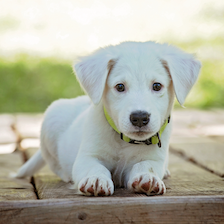

In [4]:
import numpy as np
from PIL import Image

dog_png = np.array(Image.open('images/dog.png'))
display(Image.open('images/dog.png'))

In [5]:
from keras.applications import efficientnet

predictions = hub_efficientb0.predict(dog_png[np.newaxis,:])
efficientnet.decode_predictions(predictions)

1/1 [==============================] - 1s 1s/step


[[('n02099712', 'Labrador_retriever', 0.3682939),
  ('n02104029', 'kuvasz', 0.19339854),
  ('n02099601', 'golden_retriever', 0.061458297),
  ('n02111500', 'Great_Pyrenees', 0.05779689),
  ('n02095889', 'Sealyham_terrier', 0.017902745)]]

## 허깅페이스로 강아지 사진 분류하기

In [6]:
from transformers import pipeline

pipe = pipeline(task='image-classification', device=0,
                model='google/efficientnet-b0')
pipe('images/dog.png')

c:\Users\an9383\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 360/360 [00:00<00:00, 549.27it/s, Materializing param=efficientnet.encoder.top_conv.weight]                                            


[{'label': 'Labrador retriever', 'score': 0.36829376220703125},
 {'label': 'kuvasz', 'score': 0.1933988332748413},
 {'label': 'golden retriever', 'score': 0.061458442360162735},
 {'label': 'Great Pyrenees', 'score': 0.05779700353741646},
 {'label': 'Sealyham terrier, Sealyham', 'score': 0.01790277101099491}]

## 전이 학습으로 피스타치오 품종 분류하기

### 사전 훈련된 모델로 피스타치오 품종 분류하기

In [7]:
!gdown 10bnEC6-ZfXZFZ2mb3zoWd38TjYufanWo
!unzip -q Pistachio_Image_Dataset.zip

'gdown'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'unzip'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [20]:
pistachio_sample = np.array(Image.open(r"D:\WorkSpace\Python\hm-dl\images\Pistachio_Image_Dataset\Pistachio_Image_Dataset\Kirmizi_Pistachio\\kirmizi (1).jpg"))

pistachio_sample.shape

(600, 600, 3)

In [12]:
efficientb7 = keras.applications.EfficientNetB7()
predictions = efficientb7.predict(pistachio_sample[np.newaxis,:])
efficientnet.decode_predictions(predictions)

1/1 [==============================] - 12s 12s/step


[[('n01950731', 'sea_slug', 0.23482278),
  ('n01924916', 'flatworm', 0.20674536),
  ('n01943899', 'conch', 0.0862238),
  ('n01945685', 'slug', 0.08500538),
  ('n01955084', 'chiton', 0.028243275)]]

### 전이 학습으로 피스타치오 품종 분류하기

In [13]:
keras_efficientb0_base = keras.applications.EfficientNetB0(include_top=False)
feature_map = keras_efficientb0_base(pistachio_sample[np.newaxis,:])
feature_map.shape

16705208/16705208 [==============================] - 2s 0us/step


TensorShape([1, 18, 18, 1280])

In [27]:
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    r'D:\WorkSpace\Python\hm-dl\images\Pistachio_Image_Dataset\Pistachio_Image_Dataset',
    image_size=(224, 224),
    batch_size=16,
    validation_split=0.2,
    subset='both',
    seed=42
)

# train_ds, val_ds = keras.utils.image_dataset_from_directory(
#     'D:\WorkSpace\Python\hm-dl\images\Pistachio_Image_Dataset\Pistachio_Image_Dataset\Kirmizi_Pistachio', image_size=(224, 224), batch_size=16,
#     validation_split=0.2, subset='both', seed=42
# )

Found 2148 files belonging to 2 classes.
Using 1719 files for training.
Using 429 files for validation.


In [28]:
keras_efficientb0_base.trainable = False

In [29]:
inputs = keras.Input(shape=(224, 224, 3))
x = keras_efficientb0_base(inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

In [30]:
rmsprop = keras.optimizers.RMSprop(learning_rate=5e-5)
model.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])
hist = model.fit(train_ds, epochs=20, validation_data=val_ds)

Epoch 1/20



108/108 [==============================] - 35s 281ms/step - loss: 0.5279 - accuracy: 0.7725 - val_loss: 0.3647 - val_accuracy: 0.9207
Epoch 2/20
108/108 [==============================] - 28s 261ms/step - loss: 0.3176 - accuracy: 0.9127 - val_loss: 0.2463 - val_accuracy: 0.9371
Epoch 3/20
108/108 [==============================] - 28s 255ms/step - loss: 0.2334 - accuracy: 0.9337 - val_loss: 0.1920 - val_accuracy: 0.9464
Epoch 4/20
108/108 [==============================] - 27s 251ms/step - loss: 0.1869 - accuracy: 0.9424 - val_loss: 0.1630 - val_accuracy: 0.9557
Epoch 5/20
108/108 [==============================] - 28s 255ms/step - loss: 0.1546 - accuracy: 0.9604 - val_loss: 0.1383 - val_accuracy: 0.9604
Epoch 6/20
108/108 [==============================] - 27s 253ms/step - loss: 0.1338 - accuracy: 0.9639 - val_loss: 0.1235 - val_accuracy: 0.9674
Epoch 7/20
108/108 [==============================] - 28s 256ms/step - loss: 0.1168 - accuracy: 0.9680 - val_loss: 0.1158 - val_accuracy: 0.9

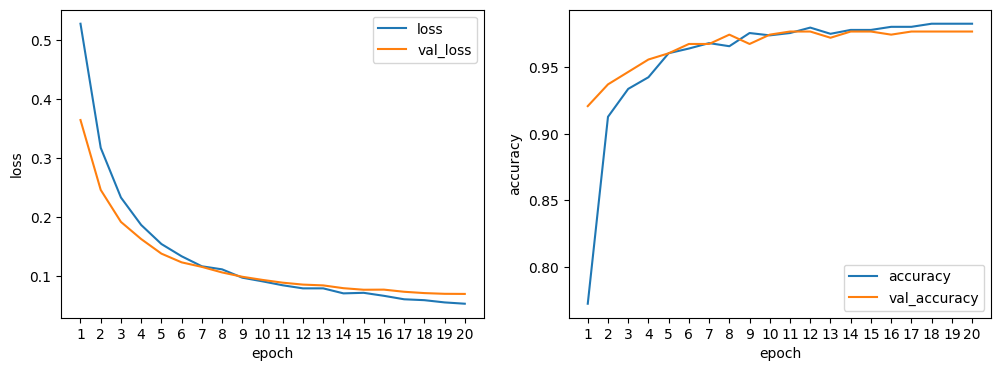

In [31]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(range(1, 21), hist.history['loss'], label='loss')
axs[0].plot(range(1, 21), hist.history['val_loss'], label='val_loss')
axs[0].set_xticks(range(1, 21))
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].legend()
axs[1].plot(range(1, 21), hist.history['accuracy'], label='accuracy')
axs[1].plot(range(1, 21), hist.history['val_accuracy'], label='val_accuracy')
axs[1].set_xticks(range(1, 21))
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('accuracy')
axs[1].legend()
plt.show()

## 미니 프로젝트

In [ ]:
kaggle_efficientb0_base = hub.KerasLayer('https://www.kaggle.com/models/tensorflow/efficientnet/frameworks/TensorFlow2/variations/b0-feature-vector/versions/1')

inputs = keras.Input(shape=(224, 224, 3))
x = layers.Rescaling(1.0 / 255.0)(inputs)
x = kaggle_efficientb0_base(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

In [ ]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])
hist = model.fit(train_ds, epochs=20, validation_data=val_ds)

Epoch 1/20
108/108 [==============================] - 16s 52ms/step - loss: 0.4000 - accuracy: 0.8534 - val_loss: 0.2474 - val_accuracy: 0.9277
Epoch 2/20
108/108 [==============================] - 5s 42ms/step - loss: 0.2003 - accuracy: 0.9459 - val_loss: 0.1597 - val_accuracy: 0.9604
Epoch 3/20
108/108 [==============================] - 5s 42ms/step - loss: 0.1402 - accuracy: 0.9628 - val_loss: 0.1271 - val_accuracy: 0.9650
Epoch 4/20
108/108 [==============================] - 4s 39ms/step - loss: 0.1098 - accuracy: 0.9697 - val_loss: 0.1234 - val_accuracy: 0.9604
Epoch 5/20
108/108 [==============================] - 5s 46ms/step - loss: 0.0913 - accuracy: 0.9727 - val_loss: 0.1035 - val_accuracy: 0.9650
Epoch 6/20
108/108 [==============================] - 4s 40ms/step - loss: 0.0776 - accuracy: 0.9791 - val_loss: 0.0906 - val_accuracy: 0.9744
Epoch 7/20
108/108 [==============================] - 4s 39ms/step - loss: 0.0684 - accuracy: 0.9808 - val_loss: 0.0803 - val_accuracy: 0.976

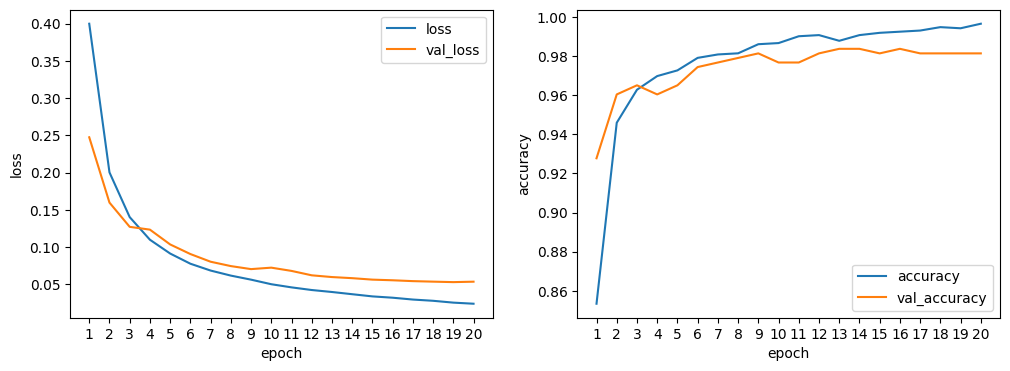

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(range(1, 21), hist.history['loss'], label='loss')
axs[0].plot(range(1, 21), hist.history['val_loss'], label='val_loss')
axs[0].set_xticks(range(1, 21))
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].legend()
axs[1].plot(range(1, 21), hist.history['accuracy'], label='accuracy')
axs[1].plot(range(1, 21), hist.history['val_accuracy'], label='val_accuracy')
axs[1].set_xticks(range(1, 21))
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('accuracy')
axs[1].legend()
plt.show()